# Logistic Regression — Heart Disease Diagnosis

## Using Logistic Regression with Clinical Data for Heart Diseases prediction

#### Author 1
- **Name:** João Pedro Fernandes de Aquino
- **GitHub:** https://github.com/Joaof14

#### Author 2
- **Name:** Anderson Carlos da Silva Morais
- **GitHub:** https://github.com/AndersonCSM

## Project Summary

Cardiovascular diseases are the leading cause of death worldwide, responsible for about 18 million deaths per year according to the WHO. Early diagnosis is crucial for successful treatment. Therefore, there is a real need for tools capable of estimating a patient's risk based on simple clinical data collected during routine consultations. It is in this context that machine learning can contribute. A classification model trained with historical data from diagnosed patients is able to learn which combinations of clinical variables are associated with the presence of heart disease and apply this learning to new patients.
The goal of this project is to build a model using logistic regression to predict the presence of heart disease based on a set of clinical data.

## Project Steps
1. Data exploration and quality checks;
2. Validate modeling assumptions;
3. Feature selection;
4. Normalization or scaling;
5. Data split;
6. Model fitting (adjustment);
7. Assessment;
8. Coefficient or feature-importance analysis;
9. Residual/error analysis;
10. Report.

todo:
Padronizar titulos portugues dos graficos

## Step 1: Data Exploration and Quality Checks
#### Collecting evidence about the dataset before making modeling decisions.

The project uses the Heart Disease Cleveland dataset (UCI Machine Learning Repository – available at https://archive.ics.uci.edu/dataset/45/heart+disease), with records from 303 patients and 13 clinical variables. The diagnoses were confirmed by cardiac catheterization, which ensures reliable labels. The variables include:

- **age** — patient's age in years;
- **sex** — biological sex (1 = male, 0 = female);
- **cp** — type of chest pain: typical angina (1), atypical (2), non-anginal (3) or asymptomatic (4);
- **trestbps** — resting blood pressure in mmHg;
- **chol** — serum cholesterol total in mg/dl;
- **fbs** — fasting blood sugar > 120 mg/dl (1 = yes, 0 = no);
- **restecg** — resting ECG result: normal (0), ST-T wave abnormality (1) or left ventricular hypertrophy (2);
- **thalach** — maximum heart rate achieved during exercise test;
- **exang** — exercise-induced angina (1 = yes, 0 = no);
- **oldpeak** — ST segment depression during exercise, indicator of ischemia;
- **slope** — slope of the ST segment at peak exercise: upsloping (1), flat (2) or downsloping (3);
- **ca** — number of major vessels colored by fluoroscopy (0-3);
- **thal** — thalassemia: normal (3), fixed defect / previous infarct (6) or reversible defect / active ischemia (7);

The output is the target variable, which indicates the original diagnosis from 0 to 4, binarized to 0 (no disease) and 1 (with disease) before training.


Steps:

1. **Initial Inspection**
   * `df.info()`: check the number of rows and columns, and the data types (int, float, object).
   * `df.describe()`: obtain a quick statistical summary (mean, standard deviation, minimum, maximum, and quartiles).

2. **Data Quality Validation**
   * **Missing Values:** check whether missing data exist (`df.isnull().sum()`) and define a strategy (input using median for 'ca' and 'thal').
   * **Duplicate Data:** identify and remove identical readings that may distort the analysis (`df.duplicated().sum()`).
   * **Target Variable** Binarize the target variable: transform original values (0-4) to binary (0 = no disease, 1 = with disease);

3. **Univariate Analysis**
   * **Distribution:** plot histograms to understand how each sensor's data is distributed.
   * **Outlier Detection:** use boxplots to identify extreme values that deviate from the expected plant pattern.

4. **Bivariate and Multivariate Analysis**
   * **Correlation Matrix:** compute indices such as Pearson's correlation to quantify the strength of the relationship between variables.
   * **Visual Trends:** create box plots crossing the predictor variables with the target variable to validate hypotheses visually.For categorical predictors, stacked bar charts are used to show the proportion of the target across each category



In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
)

In [3]:
# Load the Heart Disease dataset from UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for the dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

# Read the dataset
df = pd.read_csv(url, header=None, names=columns, na_values="?")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows of the dataset:")
df.head(10)

Dataset shape: (303, 14)

First rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


### 1.1 Initial inspection

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### 1.2 Data Quality Validation

In [5]:
# Verificando valores duplicados
print("Linhas duplicadas:")
print(df.duplicated().sum())

# Verificando valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Linhas duplicadas:
0

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [6]:
# Tratamento de missing values
# Para 'ca' e 'thal' vamos preencher com a mediana
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Verificar se ainda há missing
print("\nApós preenchimento:")
print(df.isnull().sum())


Após preenchimento:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
# Diagnóstico
print("Antes:")
print(df.isna().sum()[df.isna().sum() > 0])

# Garantir tipo numérico e converter lixo para NaN
for col in ["ca", "thal"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Imputar com mediana
for col in ["ca", "thal"]:
    df[col] = df[col].fillna(df[col].median())

# Validação final
print("\nDepois:")
print(df.isna().sum()[df.isna().sum() > 0])

Antes:
Series([], dtype: int64)

Depois:
Series([], dtype: int64)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [9]:
# Binarização da variável alvo
# Original: 0 = sem doença; 1,2,3,4 = doença (diferentes níveis de gravidade)
df["target_binary"] = (df["target"] > 0).astype(int)

# Visualizar distribuição da target original e binária
print("\nDistribuição original:")
print(df["target"].value_counts())
print("\nDistribuição binária:")
print(df["target_binary"].value_counts())


Distribuição original:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Distribuição binária:
target_binary
0    164
1    139
Name: count, dtype: int64


### 1.3. Univariate Analysis

#### Distribution

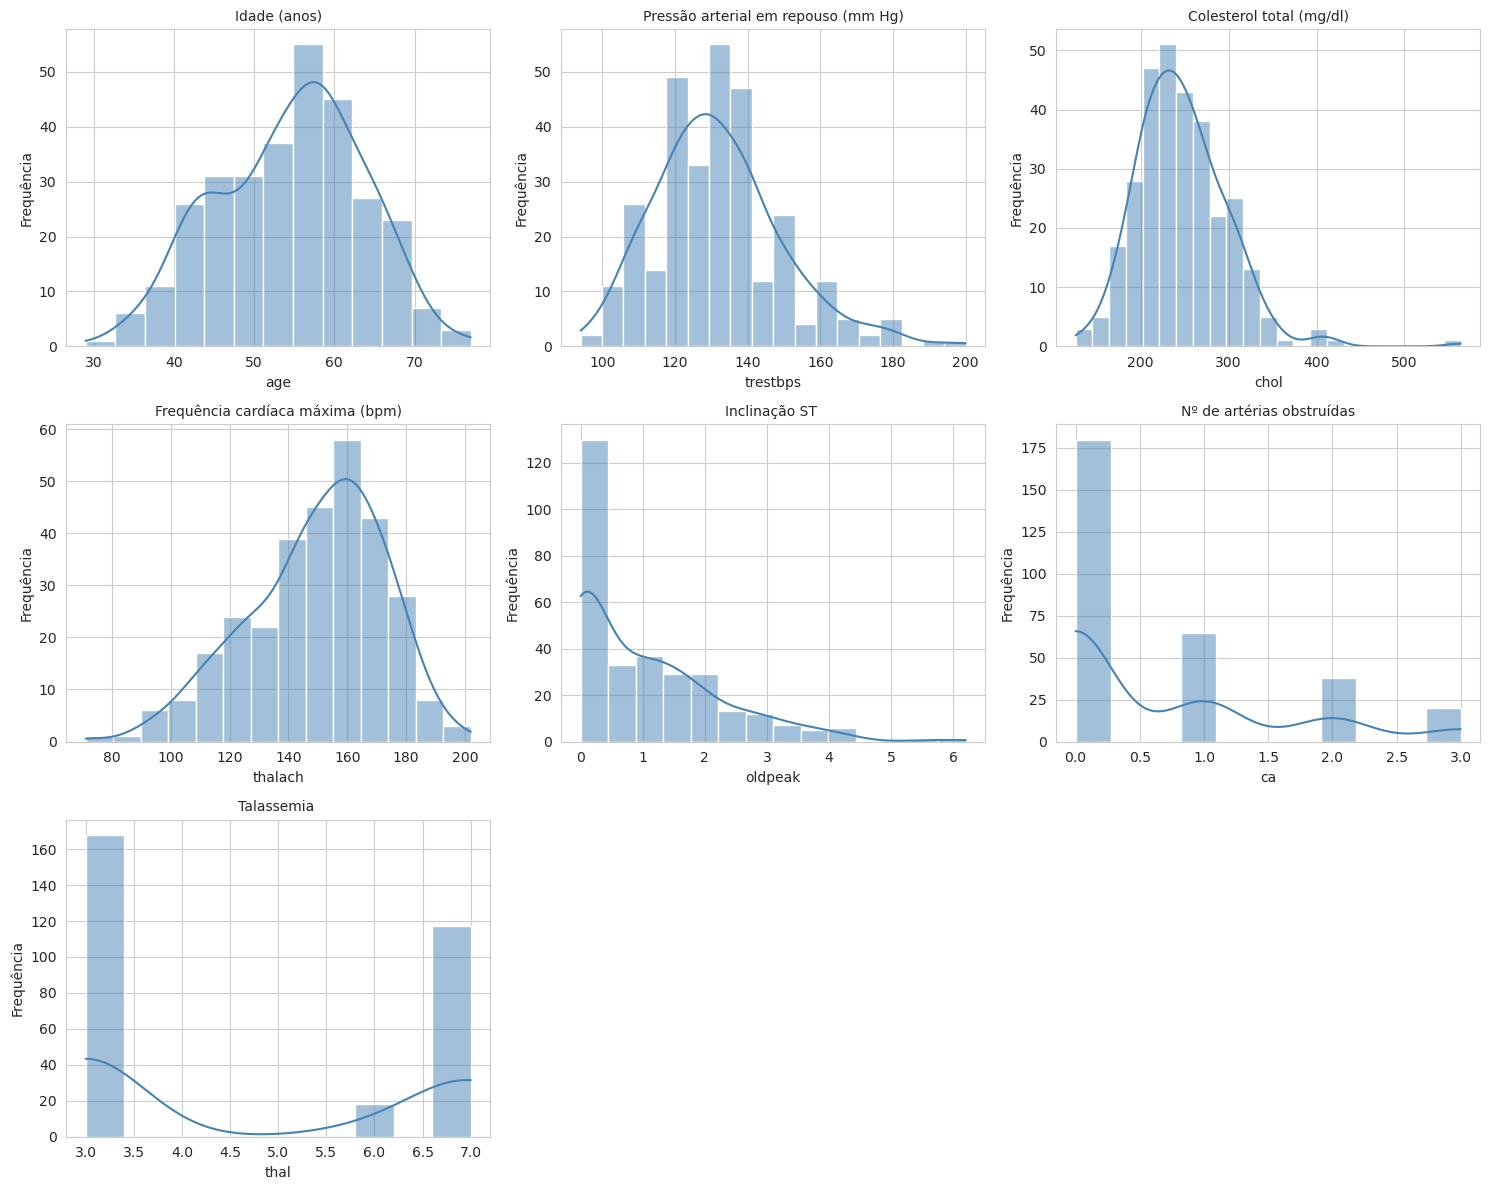

In [10]:
# Lista das variáveis numéricas (excluindo target original e a nova binária)
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]

# Títulos descritivos em português (longos, mesma ordem de num_cols)
var_titles = [
    "Idade (anos)",
    "Pressão arterial em repouso (mm Hg)",
    "Colesterol total (mg/dl)",
    "Frequência cardíaca máxima (bpm)",
    "Inclinação ST ",
    "Nº de artérias obstruídas",
    "Talassemia ",
]

# Configurar estilo dos gráficos
sns.set_style("whitegrid")

# --- Histogramas com KDE ---
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(num_cols, var_titles)):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(title, fontsize=10)
    # axes[i].set_xlabel(col)  mantém o nome original da coluna no eixo X
    axes[i].set_ylabel("Frequência")

# Remove subplots não utilizados (temos 7 variáveis, grade 3x3 = 9 espaços)
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observações:**
A maioria das variáveis contínuas (idade, pressão arterial em repouso, colesterol total, frequência cardíaca máxima) apresenta distribuição aproximadamente normal ou levemente assimétrica.
A inclinação ST e o número de artérias obstruídos têm forte assimetria à direita, com muitos zeros e cauda para valores altos

**Notes:**
Most continuous variables (age, resting blood pressure, total cholesterol, maximum heart rate) show an approximately normal or slightly skewed distribution.
ST depression and the number of obstructed vessels exhibit strong right skewness, with many zeros and a tail towards high values.

#### Outliers

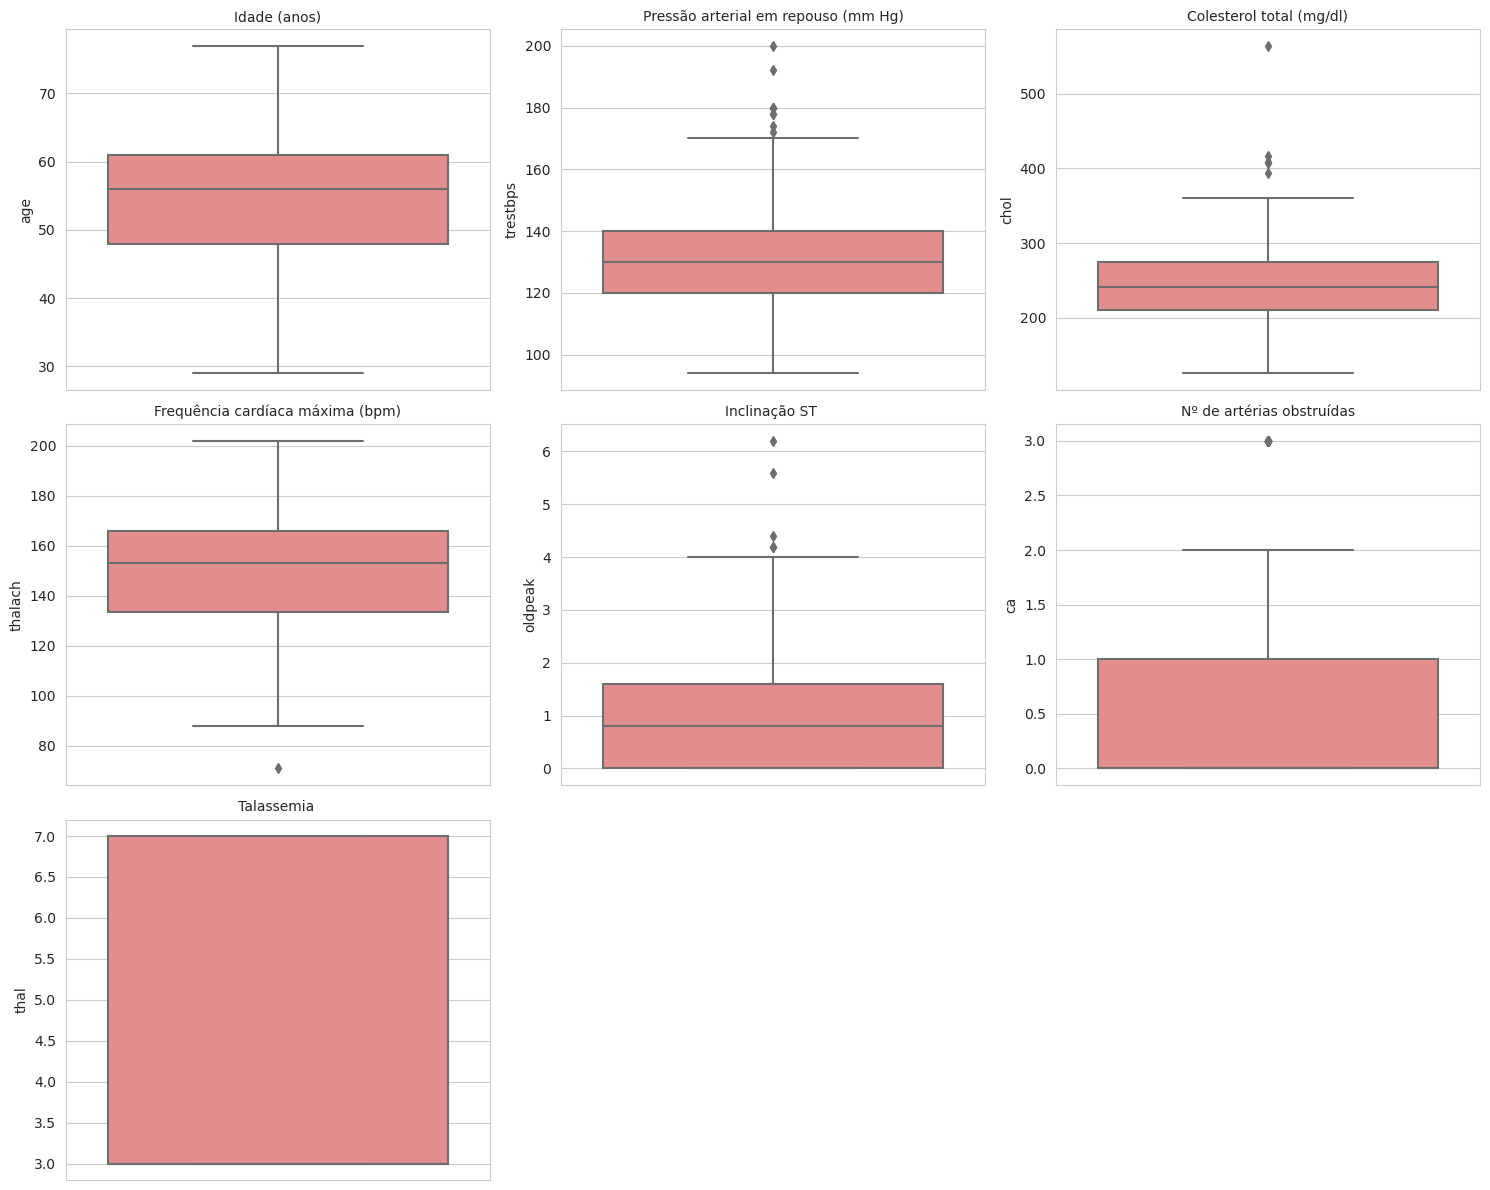

In [11]:
# Boxplots para detecção de outliers ---
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(num_cols, var_titles)):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(title, fontsize=10)
    axes[i].set_ylabel(col)

if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observações:** Foram identificados outliers principalmente em Pressão Arterial em repouso e Número de artérias coronárias com obstrução visível na fluoroscopia, por isso será realizado uma quantificação deles para definir os pŕoximos passos.


**Notes:**
Outliers were identified primarily in resting blood pressure and the number of coronary arteries with visible blockages on fluoroscopy; therefore, these will be quantified to determine the next steps


In [12]:
# Quantificando os outliers
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)


for col, titulo in zip(num_cols, var_titles):
    print(f"{titulo}: {count_outliers_iqr(df, col)} outliers")

Idade (anos): 0 outliers
Pressão arterial em repouso (mm Hg): 9 outliers
Colesterol total (mg/dl): 5 outliers
Frequência cardíaca máxima (bpm): 1 outliers
Inclinação ST : 5 outliers
Nº de artérias obstruídas: 20 outliers
Talassemia : 0 outliers


**Observações:** O dataset é pequeno (303 amostras) e os outliers são clinicamente significativos. Removê-los reduziria poder estatístico e poderia enviesar o modelo. Além disso, eles representam uma porcentagem baixa do total de amostras, então todos serão mantidos. 

**Notes:** The dataset is small (303 samples) and the outliers are clinically significant. Removing them would reduce statistical power and could bias the model. Furthermore, they represent a small percentage of the total samples, so all of them will be retained. 

### 1.4. Multivariate Analysis

#### Correlation Matrix

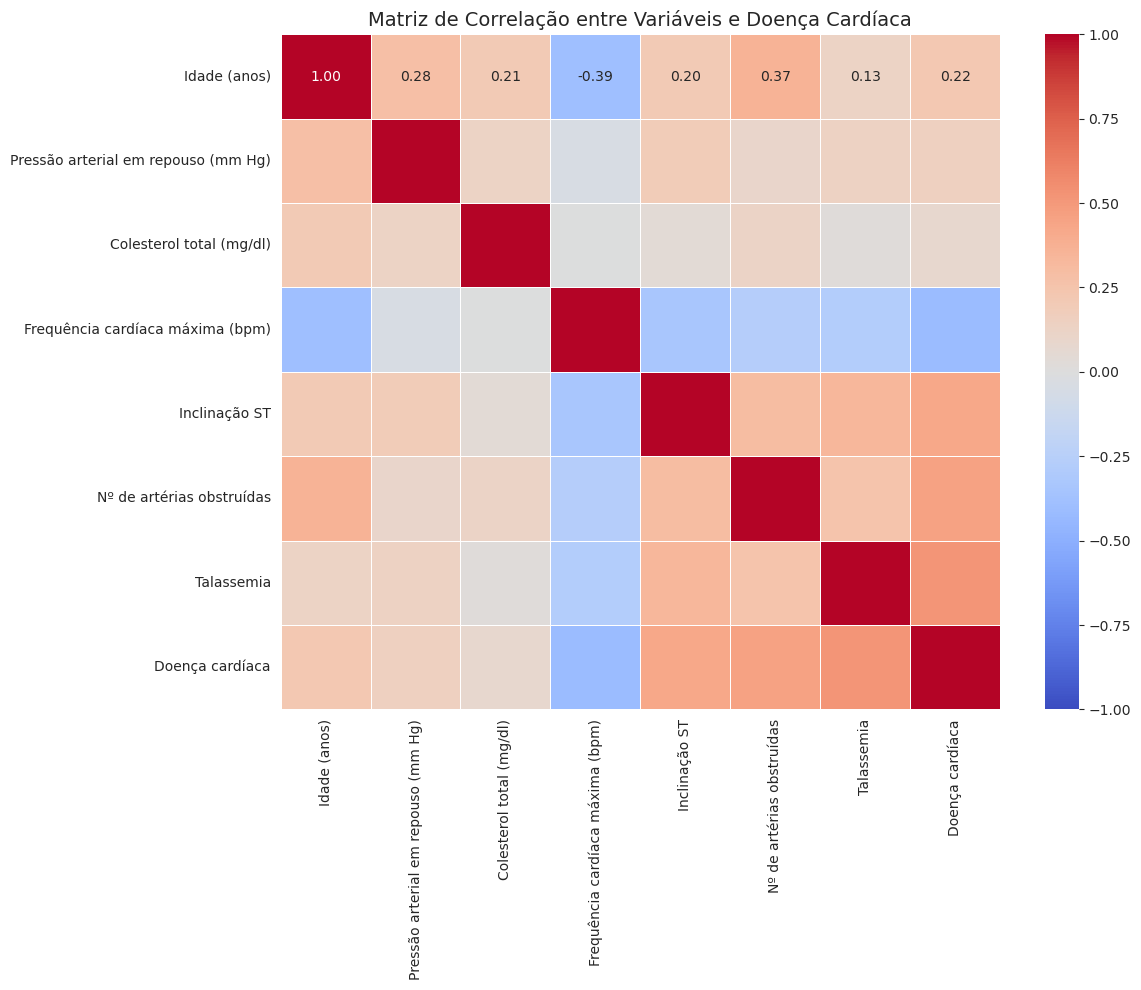

In [13]:
# Seleciona todas as variáveis numéricas + target binário
num_cols_all = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca",
    "thal",
    "target_binary",
]

# Nomes em português para exibição (mesma ordem)
nomes_pt = [
    "Idade (anos)",
    "Pressão arterial em repouso (mm Hg)",
    "Colesterol total (mg/dl)",
    "Frequência cardíaca máxima (bpm)",
    "Inclinação ST",
    "Nº de artérias obstruídas",
    "Talassemia",
    "Doença cardíaca",
]

# Calcular correlação
corr = df[num_cols_all].corr()

# Renomear linhas e colunas para português
corr.index = nomes_pt
corr.columns = nomes_pt

# Plotar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
)
plt.title("Matriz de Correlação entre Variáveis e Doença Cardíaca", fontsize=14)
plt.tight_layout()
plt.show()

**Observações:** É possível notar que não há correlação forte entre nenhuma das variáveis independentes, ou seja não há multicolinearidade. A detecção de multicolinearidade é relevante também na regressão logística, pois pode afetar a estabilidade dos coeficientes.Assim, a verificação é feita como uma boa prática de prevenção para evitar problemas no modelo a ser desenvolvido.

**Notes:** It can be seen that there is no strong correlation between any of the independent variables; in other words, there is no multicollinearity. Detecting multicollinearity is also important in logistic regression, as it can affect the stability of the coefficients. Therefore, this check is performed as a preventive measure to avoid problems in the model being developed.

#### Visual Trends

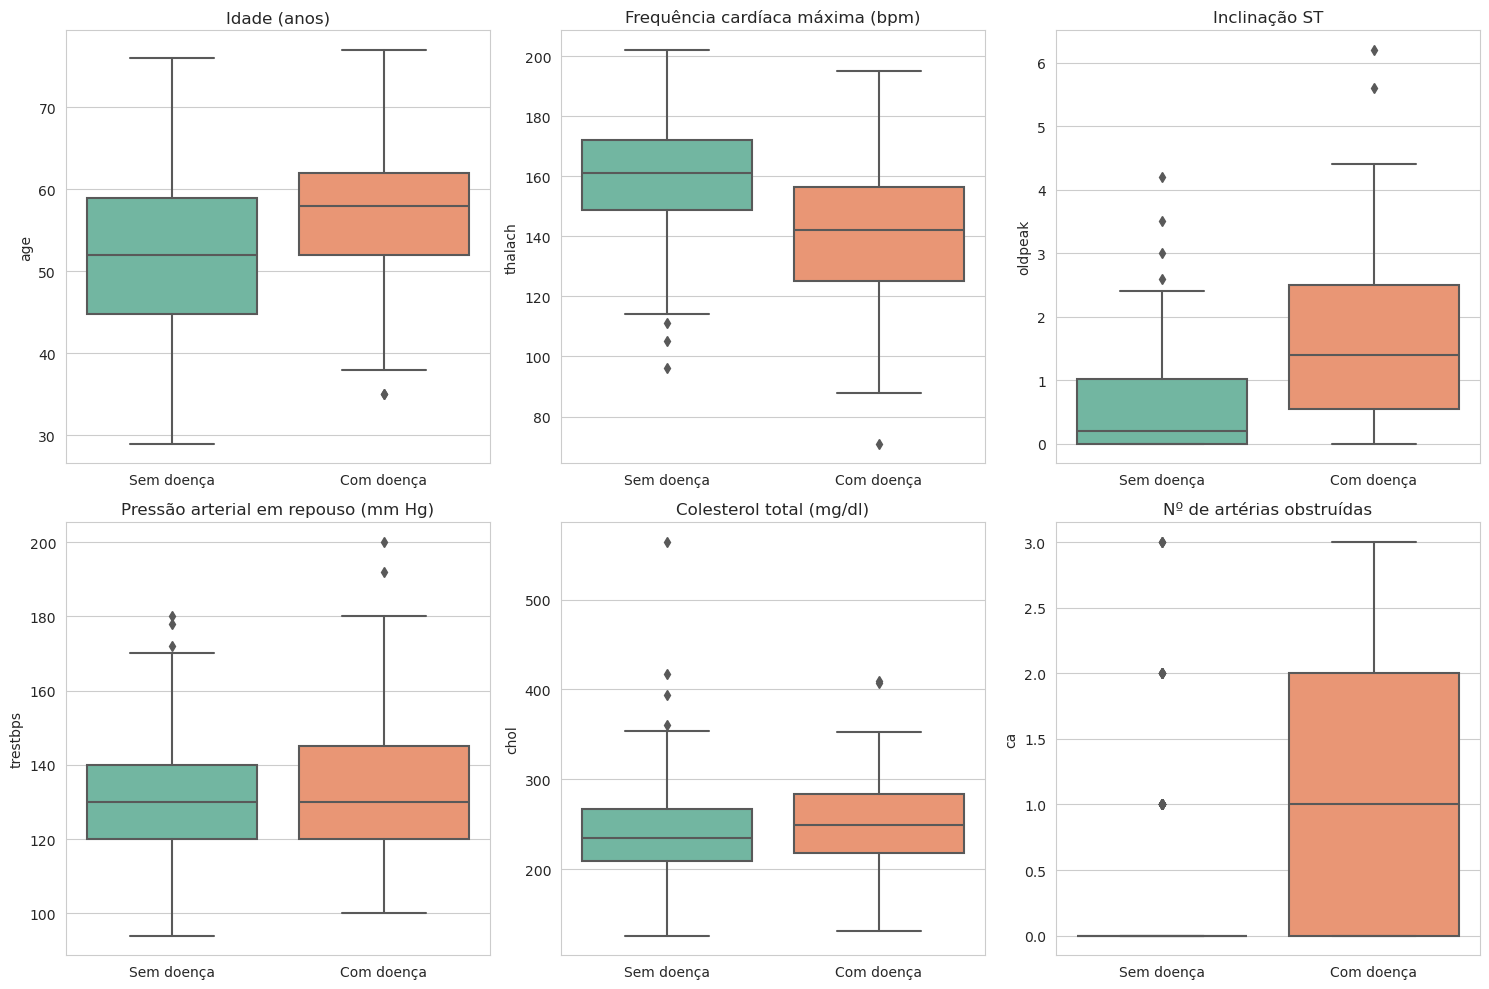

In [14]:
# Variáveis numéricas que queremos comparar
vars_cont = ["age", "thalach", "oldpeak", "trestbps", "chol", "ca"]

# Títulos em português para cada uma
titles_cont = [
    "Idade (anos)",
    "Frequência cardíaca máxima (bpm)",
    "Inclinação ST",
    "Pressão arterial em repouso (mm Hg)",
    "Colesterol total (mg/dl)",
    "Nº de artérias obstruídas",
]

# Criar subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # facilita iteração

for i, (var, titulo) in enumerate(zip(vars_cont, titles_cont)):
    sns.boxplot(x="target_binary", y=var, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(titulo, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["Sem doença", "Com doença"])
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

**Observações:** 
- Idade tem baixo poder discriminatório isolado (grande sobreposição).
- Frequência cardíaca máxima é bom preditor: quanto maior, menor a chance de doença (fator protetor).
- Nº de artérias obstruídas tem excelente poder: pacientes sem doença têm zero.
- Inclinação ST mostra valores muito mais altos no grupo com doença.

**Notes:** 
- Age has low predictive power on its own (significant overlap).
- Maximum heart rate (thalach) is a good predictor: the higher it is, the lower the risk of disease (protective factor).
- The number of blocked arteries (ca) is an excellent predictor: patients without the disease have zero.
- ST-segment depression (oldpeak) is much more pronounced in the group with the disease.

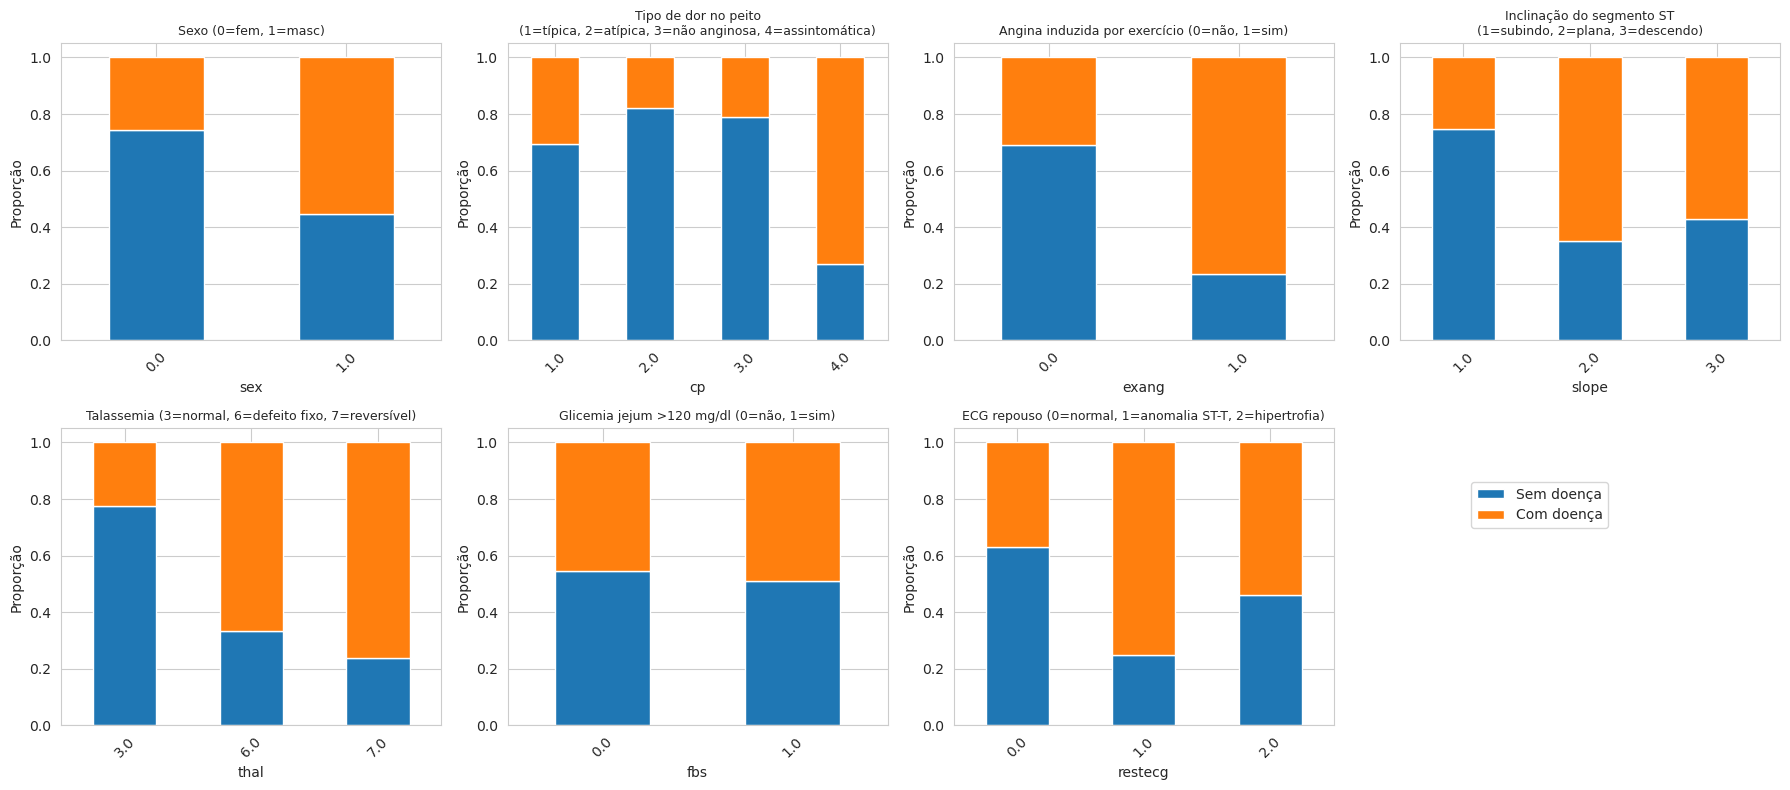

In [15]:
categoricas = ["sex", "cp", "exang", "slope", "thal", "fbs", "restecg"]

# Títulos descritivos em português
cat_titles = [
    "Sexo (0=fem, 1=masc)",
    "Tipo de dor no peito\n(1=típica, 2=atípica, 3=não anginosa, 4=assintomática)",
    "Angina induzida por exercício (0=não, 1=sim)",
    "Inclinação do segmento ST\n(1=subindo, 2=plana, 3=descendo)",
    "Talassemia (3=normal, 6=defeito fixo, 7=reversível)",
    "Glicemia jejum >120 mg/dl (0=não, 1=sim)",
    "ECG repouso (0=normal, 1=anomalia ST-T, 2=hipertrofia)",
]

# Criar figura 2x4 (8 espaços, usaremos 7)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (cat, titulo) in enumerate(zip(categoricas, cat_titles)):
    # Tabela cruzada normalizada (proporção por categoria)
    cross = pd.crosstab(df[cat], df["target_binary"], normalize="index")
    cross.plot(kind="bar", stacked=True, ax=axes[i], color=["#1f77b4", "#ff7f0e"], legend=False)
    axes[i].set_title(titulo, fontsize=9)
    axes[i].set_xlabel(cat)
    axes[i].set_ylabel("Proporção")
    axes[i].tick_params(axis="x", rotation=45)

# Remover o último subplot vazio (pois temos 7 variáveis e 8 espaços)
fig.delaxes(axes[-1])

# Adicionar legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["Sem doença", "Com doença"], loc="upper right", bbox_to_anchor=(0.9, 0.4))

plt.tight_layout()
plt.show()

**Observações:** 
- O sexo masculino costuma ser mais propenso à doença
- A dor mais comum é assintomática.
- A taxa de glicemia/diabetes não costuma fazer grande diferença na proporção de doentes.
- o ECG anômalo pode ser um grande indicativo da doença.
- Talassemia com defeito fixo ou reversível pode ser um preditor forte da doença.

**Notes:** 
- Males are generally more prone to the disease.
- The most common form of the disease is asymptomatic.
- Blood glucose levels or diabetes status do not generally make a significant difference in the proportion of patients.
- An abnormal ECG can be a strong indicator of the disease.
- Thalassemia with a fixed or reversible defect can be a strong predictor of the disease.

## Step 2: Validate Modeling Assumptions
Interpret the evidence from Step 1 and decide whether the regression model is appropriate.



- ***Confirmar variável alvo binária:*** COMPLETED IN STEP 1.2

- ***Verificar tendências de separabilidade:*** REALIZADO NA ETAPA 1.2


======================================================================================

- ***Confirm binary target:*** COMPLETED IN STEP 1.2

- ***Check separability trends:*** COMPLETED IN STEP 1.2



## Step 3: Feature Selection
Choose the input variables that will enter the model.




In [16]:
# Cópia do dataframe original para se trabalhar
df_f = df.copy()
df_f.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'target_binary'],
      dtype='object')

In [17]:
X = df_f.drop(columns=["target", "target_binary"])
y = df_f["target_binary"]
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


## Step 4 and 5: Normalization or Scaling and Data Split

- Place features on a common scale after the feature set has been decided.
- Separate data used for learning from data used only for evaluation.



In [18]:
# Scaler padrão, utiliza a média para centralizar os dados.
scaler = StandardScaler()

# Separando conjunto de treinamento e teste 80% para treino, 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizando conjunto de treino e conjunto de teste
X_train_scaled = scaler.fit_transform(X_train)  # train sempre fit_transform
X_test_scaled = scaler.transform(X_test)  # teste sempre transform

df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
df_X_train_scaled

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.729485,0.68313,0.870169,-0.395692,0.458139,-0.411196,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.179973
1,0.050166,0.68313,-1.184278,-0.054513,0.230598,-0.411196,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070
2,-0.061212,-1.46385,-1.184278,0.059213,0.723605,2.431930,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,-0.878070
3,-0.061212,0.68313,-1.184278,-1.305501,1.121803,-0.411196,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,1.179973
4,0.272924,-1.46385,0.870169,0.514117,-0.167601,-0.411196,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.179973
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,0.829818,-1.46385,0.870169,0.514117,2.733557,-0.411196,1.022996,0.310836,-0.696177,0.179210,0.675060,-0.689715,-0.878070
238,1.720848,0.68313,0.870169,0.798433,-1.438042,-0.411196,-0.981579,-1.102621,1.436416,1.428521,2.308704,-0.689715,1.179973
239,1.386712,0.68313,0.870169,-0.623144,-0.395142,-0.411196,1.022996,-0.925938,1.436416,1.428521,0.675060,1.581184,1.179973
240,1.609469,0.68313,-0.157055,0.514117,0.078903,-0.411196,1.022996,-0.175039,-0.696177,0.893102,0.675060,2.716634,1.179973


## Step 6: Model Fitting (Adjustment)
Train the selected model with the prepared dataset.


***Com base nas análises anteriores, definimos a configuração final:***

- **Escalonador**: StandardScaler()
- **Divisão Treino/Teste**: 80% / 20%.

Treinamos dois modelos regularizados:
- **Ridge (L2)** : penaliza a soma dos quadrados dos coeficientes.
- **Lasso (L1)** : penaliza a soma dos valores absolutos, podendo zerar coeficientes.

Ambos utilizam validação cruzada interna de 5 folds para escolha automática do hiperparâmetro `alpha`.  


=============================================================================================================================================


***Based on the previous analyses, we defined the final configuration***

- **Scaler**: `StandardScaler()`
- **Train/Test Split**: 80% / 20%.

We trained two regularized models:
- **Ridge (L2)**: penalizes the sum of squared coefficients.
- **Lasso (L1)**: penalizes the sum of absolute values, which can zero out coefficients.

Both use internal 5‑fold cross‑validation to automatically select the `alpha` hyperparameter.


In [19]:
# Ridge Final
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train_scaled, y_train)

lasso = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5)
lasso.fit(X_train_scaled, y_train)

print(f"Melhor alpha Ridge: {ridge.alpha_:.4f}")
print(f"Melhor alpha Lasso: {lasso.alpha_:.4f}")

Melhor alpha Ridge: 53.3670
Melhor alpha Lasso: 0.0142


In [20]:
# Na regressão logística usa-se o parâmetro da logística
c1 = 1 / ridge.alpha_
c2 = 1 / lasso.alpha_

print(f"c1 = {c1}")
print(f"c2 = {c2}")

c1 = 0.01873817422860383
c2 = 70.54802310718641


In [21]:
model = LogisticRegression(solver="liblinear", random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# usando parâmetro ridge
model2 = LogisticRegression(solver="liblinear", random_state=42, max_iter=1000, penalty="l2", C=c1)
model2.fit(X_train_scaled, y_train)

# usando parâmetro lasso
model3 = LogisticRegression(solver="liblinear", random_state=42, max_iter=1000, penalty="l1", C=c2)
model3.fit(X_train_scaled, y_train)

LogisticRegression(C=70.54802310718641, max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')

In [22]:
# Número de iterações até convergência
print("Iterações - model (base):", model.n_iter_[0])
print("Iterações - model2 (L2 com C do Ridge):", model2.n_iter_[0])
print("Iterações - model3 (L1 com C do Lasso):", model3.n_iter_[0])

Iterações - model (base): 5
Iterações - model2 (L2 com C do Ridge): 4
Iterações - model3 (L1 com C do Lasso): 10


## Step 7: Assessment
Measure how well the model predicts unseen data.


In [23]:
# Se quiser, ajuste os nomes:
modelos = {
    "Logística base": model,
    "Logística + C do Ridge": model2,
    "Logística + C do Lasso": model3,
}

resultados = []
roc_data = {}

for nome, m in modelos.items():
    # Predições
    y_pred = m.predict(X_test_scaled)
    y_prob = m.predict_proba(X_test_scaled)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    resultados.append(
        {"Modelo": nome, "C": float(m.C), "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": auc}
    )

    # Dados da ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[nome] = (fpr, tpr, auc)

# DataFrame de comparação
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logística base,1.000000,0.868852,0.812500,0.928571,0.866667,0.951299
1,Logística + C do Ridge,0.018738,0.852459,0.806452,0.892857,0.847458,0.959957
2,Logística + C do Lasso,70.548023,0.868852,0.812500,0.928571,0.866667,0.950216


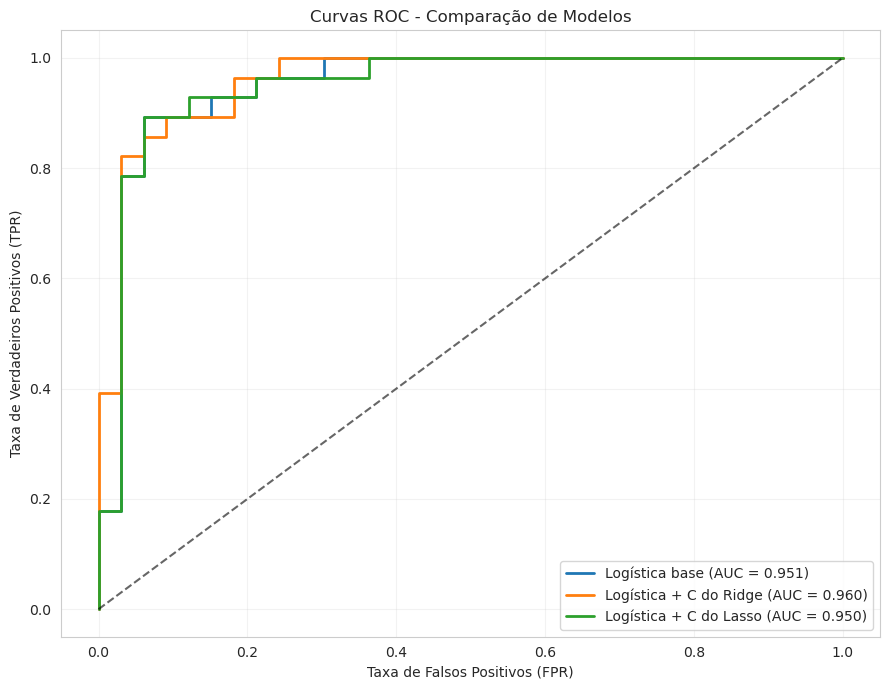

In [24]:
# Curvas ROC
plt.figure(figsize=(9, 7))

for nome, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC = {auc:.3f})")

# Linha de referência (aleatório)
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)

plt.title("Curvas ROC - Comparação de Modelos")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Step 8: Coefficient or Feature-Importance Analysis
Explain how each variable affects the prediction.



***Contexto:*** Como o problema se trata de uma doença no coração, existe o entendimento de que o cenário em que você está com a doença cardiaca e o diagnóstico não a identifica é o mais grave, logo, devemos penalizar os Falsos Negativos (FN), casos positivos erroneamente classificados como negativos.  A métrica adequada é o Recall, como todos apresentaram o mesmo valor para o Recall, vamos utilizar o modelo que apresentou os melhores valores para as demais métricas, sendo o modelo de regressão logística sem normalização.



***Context:*** Since the problem involves a heart condition, it is generally understood that the most serious scenario is one in which you have heart disease but the diagnosis fails to identify it; therefore, we should penalize false negatives (FN)—positive cases that are mistakenly classified as negative. The appropriate metric is Recall. Since all models had the same Recall value, we will use the model that performed best on the other metrics, which is the unnormalized logistic regression model.



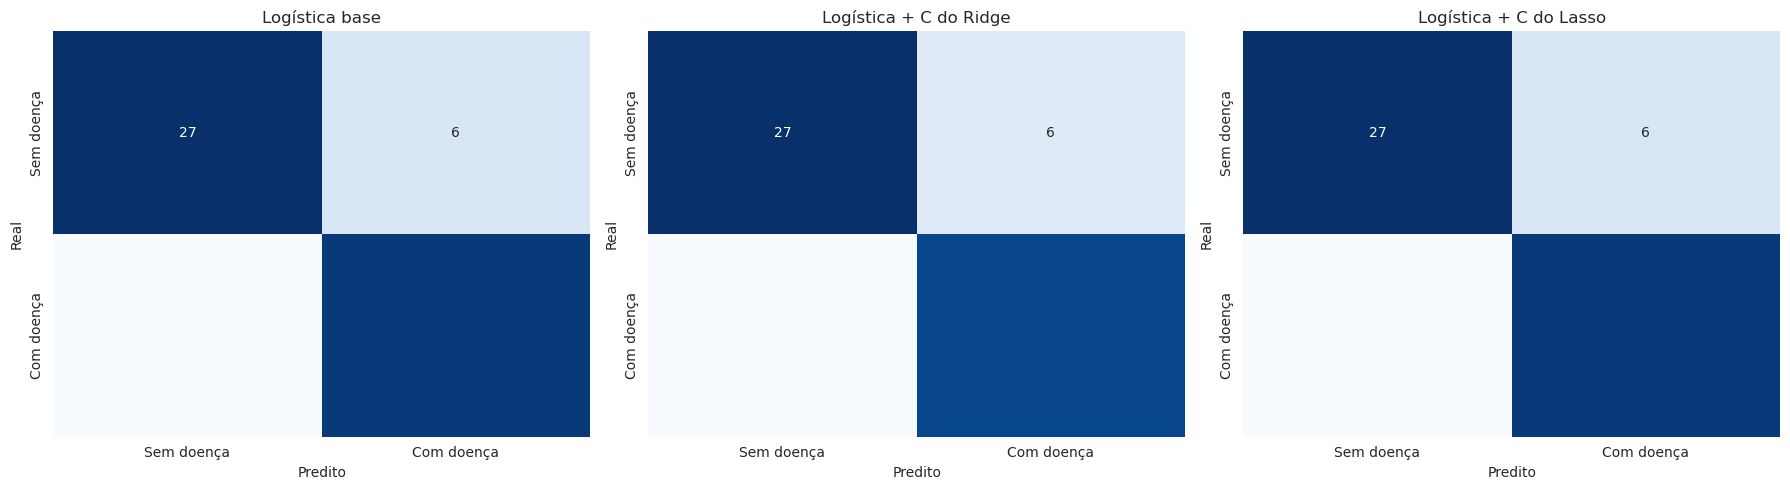

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, m) in zip(axes, modelos.items()):
    y_pred = m.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Sem doença", "Com doença"],
        yticklabels=["Sem doença", "Com doença"],
    )

    ax.set_title(nome)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

## Step 9: Residual/Error Analysis
Check whether the prediction errors are well-behaved.


## Step 10: Report




1. No pré-processamento:
   
    a) Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam, escolha o metodo de imputação através da mediana.

    **REALIZADO NA ETAPA 1.2**

    b) Obtenha a binarizac¸ao da variável target, transformando os valores originais (0 a 4) em uma variável binária (0 = sem doença, 1 = com doença).

    **REALIZADO NA ETAPA 1.2**

    c) Realize a divisao treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

    **REALIZADO NA ETAPA 5**

    d) Faça o escalonamento das features numéricas contínuas (age, trestbps, chol, thalach, oldpeak) com StandardScaler.

    **REALIZADO NA ETAPA 4**

2. Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os
seguintes parâmetros: "solver=’liblinear’, random state=42 e max iter=1000." Indique quantas iterações foram necessárias para a convergência do modelo
    
    **REALIZADO NA ETAPA 7**

1. Avaliar o modelo utilizando os dados de teste e calcular as seguintes metrícas:
    
    a) Acurácia:
    b) Precisão:
    c) Recall:
    d) F1-score:
    e) Curva ROC com valor de AUC:


#### 10.3 Final model

In [26]:
# Escolha do modelo final
best_name = "Logística base"
best_model = model

# Métricas no teste
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, zero_division=0)
rec_best = recall_score(y_test, y_pred_best, zero_division=0)
f1_best = f1_score(y_test, y_pred_best, zero_division=0)
auc_best = roc_auc_score(y_test, y_prob_best)

print(f"Modelo final: {best_name}")
print(f"Acurácia : {acc_best:.4f}")
print(f"Precisão : {prec_best:.4f}")
print(f"Recall   : {rec_best:.4f}")
print(f"F1-score : {f1_best:.4f}")
print(f"ROC-AUC  : {auc_best:.4f}")
print(f"Iterações: {best_model.n_iter_[0]}")

Modelo final: Logística base
Acurácia : 0.8689
Precisão : 0.8125
Recall   : 0.9286
F1-score : 0.8667
ROC-AUC  : 0.9513
Iterações: 5


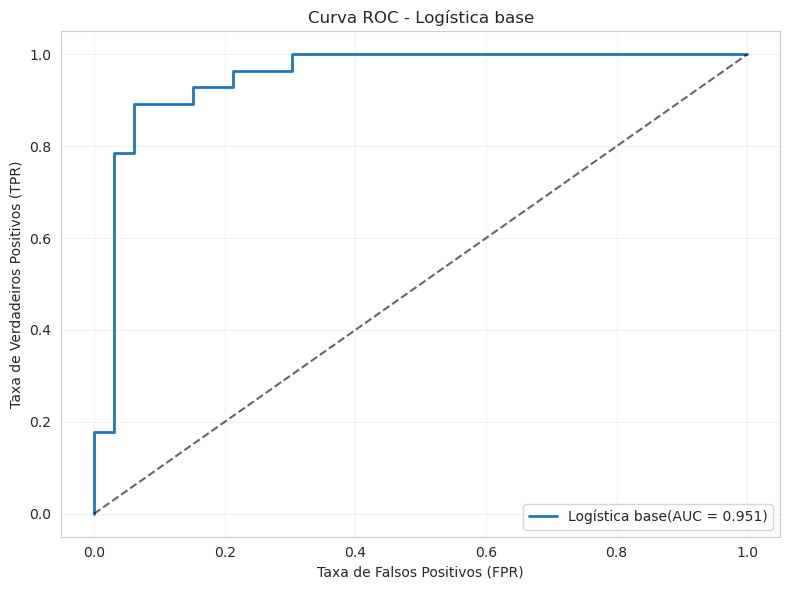

In [27]:
# Recupera fpr, tpr e auc do modelo desejado
fpr, tpr, auc = roc_data["Logística base"]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logística base(AUC = {auc:.3f})")

# Linha de referência (aleatório)
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)

plt.title("Curva ROC - Logística base")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

***Observações:*** Com um recall de 93%, este modelo seria muito eficaz como ferramenta de triagem inicial em um ambulatório de cardiologia. Ele identificaria corretamente a grande maioria dos pacientes que realmente têm doença cardíaca, permitindo que recebam tratamento oportuno. O alto ROC-AUC garante que as classificações de risco do modelo são altamente confiáveis. Este modelo de regressão logística base demonstra excelente poder discriminatório, alta sensibilidade e boa acurácia geral. Está bem adequado para a tarefa proposta de apoio ao diagnóstico. Não são necessários ajustes adicionais de regularização, pois o modelo já apresenta desempenho ótimo no conjunto de teste.


***Notes:*** With a recall of 93%, this model would be very effective as an initial screening tool in a cardiology clinic. It would correctly identify the vast majority of patients who truly have heart disease, allowing them to receive timely treatment. The high ROC‑AUC reassures that the model's risk rankings are highly reliable.This baseline logistic regression model demonstrates excellent discriminatory power, high sensitivity, and good overall accuracy. It is well‑suited for the intended diagnostic support task. No further regularization adjustments are needed, as the model already performs optimally on the test set.

In [28]:
import sys
!{sys.executable} -m pip freeze > requirements.txt
!head -n 20 requirements.txt

aiobotocore @ file:///croot/aiobotocore_1701291493089/work
aiohttp @ file:///croot/aiohttp_1707342283163/work
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
alabaster @ file:///home/ktietz/src/ci/alabaster_1611921544520/work
altair @ file:///croot/altair_1687526041770/work
anaconda-anon-usage @ file:///croot/anaconda-anon-usage_1697038922993/work
anaconda-catalogs @ file:///croot/anaconda-catalogs_1685727283692/work
anaconda-client @ file:///croot/anaconda-client_1708640631824/work
anaconda-cloud-auth @ file:///croot/anaconda-cloud-auth_1697462711326/work
anaconda-navigator @ file:///croot/anaconda-navigator_1704813276856/work
anaconda-project @ file:///work/ci_py311/anaconda-project_1676846728333/work
anyio @ file:///croot/anyio_1706220167567/work
appdirs==1.4.4
Apycula==0.26
archspec @ file:///croot/archspec_1697725767277/work
argon2-cffi @ file:///opt/conda/conda-bld/argon2-cffi_1645000214